# 02 — EDA sobre Parquets con RAPIDS

**Freddie Mac Single-Family Loan-Level Dataset (SFLLD)**

Análisis exploratorio sobre los **Parquet** generados por `csv_to_parquet_rapids_v2.ipynb`,
usando **RAPIDS cuDF** en GPU. El dataset combina **Origination** (características en T=0)
y **Monthly Performance** (métricas crediticias mensuales).

---

## Estructura del notebook (alineada a Freddie Mac SFLLD)

| Parte | Contenido |
|-------|-----------|
| **I. Configuración** | Drive, RAPIDS, Glosario (metadata Freddie Mac) |
| **II. Clasificación de variables** | Identificadores · Originación (num/cat) · Performance (mensual) |
| **III. Muestreo y validación** | Cluster Sampling · Bondad de ajuste · Divergencia KL · SENECA |
| **IV. EDA — Originación** | Variables numéricas (p01–p99, winsorizing) · KDE |
| **V. EDA — Performance** | Variables mensuales · Variación histórica de tasas |
| **VI. EDA — Categóricas** | Alfanuméricas · Cardinalidad · Constantes |
| **VII. Visualizaciones** | Datashader · Seaborn · Matriz de correlación |
| **VIII. Conclusiones** | Arquitectura para AFE/AFC/AFM · Poda y fases de modelado |

## I. Configuración — Drive, RAPIDS y Glosario

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
!pip install -q --extra-index-url=https://pypi.nvidia.com cudf-cu12 dask-cudf-cu12 dask-cuda rmm-cu12
!pip install -q datashader colorcet seaborn scipy
print('RAPIDS + Gráficas OK')

Tesla T4, 15360 MiB
RAPIDS + Gráficas OK


In [3]:
import os, re, gc, glob
import cudf
import dask_cudf as dc
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

DRIVE_BASE   = '/content/drive/MyDrive'
PARQUET_PATH = f'{DRIVE_BASE}/mortgage-risk/parquet/'
GLOSSARY_CSV = f'{DRIVE_BASE}/mortgage-risk/metadata/crt_glossary_tables.csv'

def spark_safe_name(s):
    return re.sub(r'[\s()≤]+', '_', s).strip('_').replace('__', '_') or 'col'

def parse_alpha_maxlen(ml):
    m = re.search(r'X\s*\((\d+)\)', str(ml), re.IGNORECASE)
    return int(m.group(1)) if m else None

def parse_enumerations(raw):
    if pd.isna(raw) or not str(raw).strip(): return []
    keys = []
    for line in str(raw).split('\n'):
        line = line.strip()
        if '=' in line:
            key = line.split('=')[0].strip()
            if key: keys.append(key)
    return keys

g = pd.read_csv(GLOSSARY_CSV)
col_position = g.iloc[:, 0].astype(str)
_rows = g.loc[col_position.str.match(r'^\d+$')].head(110).copy()

COL_FIELD, COL_ENUM, COL_TYPE, COL_MAXLEN = g.columns[1], g.columns[3], g.columns[9], g.columns[10]

COLUMN_NAMES = [spark_safe_name(n) for n in _rows[COL_FIELD].astype(str).str.strip()]
GLOSSARY_META = pd.DataFrame({
    'field_name':   _rows[COL_FIELD].astype(str).str.strip().tolist(),
    'col_safe':     COLUMN_NAMES,
    'gtype':        _rows[COL_TYPE].astype(str).str.strip().tolist(),
    'max_length':   _rows[COL_MAXLEN].astype(str).str.strip().tolist(),
    'alpha_n':      [parse_alpha_maxlen(ml) for ml in _rows[COL_MAXLEN]],
    'enumerations': [parse_enumerations(e) for e in _rows[COL_ENUM]],
})

EXPECTED = {row['col_safe']: row['enumerations'] for _, row in GLOSSARY_META.iterrows() if row['enumerations']}

print(f'Glosario cargado: {len(COLUMN_NAMES)} campos procesados.')

Glosario cargado: 110 campos procesados.


---
## II. Clasificación de variables (según glosario Freddie Mac)

Separación en **Identificadores**, **Numéricas** (Originación + Performance), **Fechas** y **Categóricas**.

In [4]:
NUMERIC_COLS = GLOSSARY_META.loc[GLOSSARY_META['gtype'] == 'NUMERIC',      'col_safe'].tolist()
DATE_COLS    = GLOSSARY_META.loc[GLOSSARY_META['gtype'] == 'DATE',          'col_safe'].tolist()
ALPHA_ALL    = GLOSSARY_META.loc[GLOSSARY_META['gtype'] == 'ALPHA-NUMERIC', :]

ID_COLS_SAFE = set(ALPHA_ALL.loc[ALPHA_ALL['alpha_n'].isna() | (ALPHA_ALL['alpha_n'] > 3), 'col_safe'].tolist())
CAT_COLS     = ALPHA_ALL.loc[ALPHA_ALL['alpha_n'].notna() & (ALPHA_ALL['alpha_n'] <= 3), 'col_safe'].tolist()
ALPHA_COLS   = ALPHA_ALL['col_safe'].tolist()

print(f'NUMERIC    : {len(NUMERIC_COLS)}  |  DATE: {len(DATE_COLS)}')
print(f'ALPHA total: {len(ALPHA_COLS)}  → Identificadores: {len(ID_COLS_SAFE)}  | Categóricos: {len(CAT_COLS)}')

NUMERIC    : 55  |  DATE: 16
ALPHA total: 39  → Identificadores: 11  | Categóricos: 28


---
## III. Muestreo y validación

### 3.1 Cluster Sampling (OOM-Safe)

Los préstamos Freddie Mac se empaquetan en *Reference Pools* (Trust/Pool).
Al muestrear por **`Loan_Identifier`** (conglomerado estadístico) en lugar de cargar todo el dataset:
- Extraemos historiales longitudinales completos.
- El filtro `isin()` en cuDF es eficiente al matchear contra ~10k IDs.
- Evitamos OOM durante el concatenamiento de particiones.

In [5]:
# Lectura lazy del dataset completo (solo metadata; sin cargar valores)
ddf = dc.read_parquet(f'{PARQUET_PATH}*/**/*.parquet', split_row_groups=True)
print(f'Total particiones Dask: {ddf.npartitions}')

ID_COL          = 'Loan_Identifier'   # El conglomerado estadistico
N_SAMPLE_LOANS  = 10_000              # N de conglomerados (prestamos) a extraer
N_PARTS_SCAN    = min(30, ddf.npartitions)   # Particiones a recorrer en Fase 2
RANDOM_SEED     = 42

# ===== FASE 1: Seleccion del conglomerado (1 particion en GPU) =====
print('\n[FASE 1] Extrayendo pool de Loan_Identifiers...')
part0_cu    = ddf.get_partition(0).compute()          # 1 particion en GPU
pool_cu     = part0_cu[ID_COL].dropna().unique()       # IDs unicos en GPU
n_pool      = len(pool_cu)
print(f'  Pool: {n_pool:,} prestamos unicos encontrados en particion 0')

n_select    = min(N_SAMPLE_LOANS, n_pool)
sampled_cu  = pool_cu.sample(n=n_select, random_state=RANDOM_SEED)
# Mover a Python set en CPU RAM (cuDF isin() acepta iterables Python directamente)
sampled_set = set(sampled_cu.to_pandas().tolist())
print(f'  Conglomerados seleccionados (random_state={RANDOM_SEED}): {len(sampled_set):,} Loan_Identifiers')

del pool_cu, sampled_cu, part0_cu; gc.collect()   # Liberar GPU completamente

# ===== FASE 2: Extraccion batch particion-por-particion =====
print(f'\n[FASE 2] Escaneando {N_PARTS_SCAN} particiones...')
parts_pd    = []
total_rows  = 0

for i in range(N_PARTS_SCAN):
    try:
        part_cu    = ddf.get_partition(i).compute()          # Cargar particion en GPU
        mask_cu    = part_cu[ID_COL].isin(sampled_set)        # Filtro GPU (sub-ms)
        matched_cu = part_cu[mask_cu]
        if len(matched_cu) > 0:
            parts_pd.append(matched_cu.to_pandas())           # Solo matching -> CPU RAM
            total_rows += len(matched_cu)
        del part_cu, mask_cu, matched_cu; gc.collect()        # Liberar GPU ahora
        if (i + 1) % 10 == 0:
            print(f'  {i+1}/{N_PARTS_SCAN} | {total_rows:,} filas acumuladas en CPU')
    except Exception as e:
        print(f'  [!] Particion {i}: {e}')
        gc.collect()

# ===== Ensamblaje en CPU RAM (sin tocar GPU) =====
if parts_pd:
    sample_pd    = pd.concat(parts_pd, ignore_index=True)
    del parts_pd; gc.collect()
    unique_loans = sample_pd[ID_COL].nunique()
    coverage     = unique_loans / len(sampled_set) * 100
    print(f'\nMuestreo por Conglomerados completado (OOM-Safe):')
    print(f'  Filas totales          : {len(sample_pd):,}')
    print(f'  Loan_Identifiers unicos: {unique_loans:,}')
    print(f'  Cobertura              : {coverage:.1f}%')
    print(f'  (Cobertura <100% = historia de algunos IDs esta en particiones >{N_PARTS_SCAN})')
else:
    print('No se encontraron filas. Fallback: particion 0 completa.')
    sample_pd = ddf.get_partition(0).compute().to_pandas()


Total particiones Dask: 66

[FASE 1] Extrayendo pool de Loan_Identifiers...
  Pool: 14,603 prestamos unicos encontrados en particion 0
  Conglomerados seleccionados (random_state=42): 10,000 Loan_Identifiers

[FASE 2] Escaneando 30 particiones...
  10/30 | 404,982 filas acumuladas en CPU
  20/30 | 405,464 filas acumuladas en CPU
  30/30 | 405,464 filas acumuladas en CPU

Muestreo por Conglomerados completado (OOM-Safe):
  Filas totales          : 405,464
  Loan_Identifiers unicos: 10,000
  Cobertura              : 100.0%
  (Cobertura <100% = historia de algunos IDs esta en particiones >30)


### 3.2 Validación empírica (Población vs Muestra)

**Q1, Mediana, Q3** de variables clave: Tasa de Interés, FICO, LTV, DTI, UPB.

In [6]:
import numpy as np
from scipy import stats
import gc

print("Validando Muestra vs Población (Bondad de Ajuste)...")

id_col = 'Loan_Identifier'
rate_col = 'Original_Interest_Rate'
fico_col = 'Borrower_Credit_Score_at_Origination'
ltv_col = 'Original_Loan_to_Value_Ratio_LTV'
dti_col = 'Debt-To-Income_DTI'
upb_col = 'Original_UPB'

# Validar que todas las columnas existan en la muestra
cols_to_check = [id_col, rate_col, fico_col, ltv_col, dti_col, upb_col]

if all(col in sample_pd.columns for col in cols_to_check):
    print("Calculando agregaciones de la Población (Dask Lazy Compute)...")
    # Población sobre 5 particiones proxy sin OOM
    pop_subset = ddf.partitions[0:min(5, ddf.npartitions)].compute()

    # ¡PASO CRÍTICO!: Desduplicar para evaluar la foto del Día 1 correctamente
    pop_unique = pop_subset.drop_duplicates(subset=[id_col])
    samp_unique = sample_pd.drop_duplicates(subset=[id_col])

    # Extracción de las series pandas (manejando Nulos)
    pop_rate = pop_unique[rate_col].dropna().to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique[rate_col].dropna()
    pop_fico = pop_unique[fico_col].dropna().to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique[fico_col].dropna()
    pop_ltv = pop_unique[ltv_col].dropna().to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique[ltv_col].dropna()
    pop_dti = pop_unique[dti_col].dropna().to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique[dti_col].dropna()
    pop_upb = pop_unique[upb_col].dropna().to_pandas() if hasattr(pop_unique, 'to_pandas') else pop_unique[upb_col].dropna()

    samp_rate = samp_unique[rate_col].dropna()
    samp_fico = samp_unique[fico_col].dropna()
    samp_ltv = samp_unique[ltv_col].dropna()
    samp_dti = samp_unique[dti_col].dropna()
    samp_upb = samp_unique[upb_col].dropna()

    def compare_metrics(pop, samp, name):
        p_q1, p_med, p_q3 = pop.quantile([0.25, 0.50, 0.75])
        s_q1, s_med, s_q3 = samp.quantile([0.25, 0.50, 0.75])

        print(f"\n[{name}] -- Validación Q1, Q2(Mediana), Q3:")
        print(f"  Población: {p_q1:.2f} | {p_med:.2f} | {p_q3:.2f}")
        print(f"  Muestra:   {s_q1:.2f} | {s_med:.2f} | {s_q3:.2f}")
        print(f"  Diferencia Mediana: {abs(p_med - s_med):.3f}")

    # Ejecutar las validaciones de las 5 métricas clave
    compare_metrics(pop_rate, samp_rate, "Original Interest Rate")
    compare_metrics(pop_fico, samp_fico, "FICO Score")
    compare_metrics(pop_ltv, samp_ltv, "Original LTV (Colateral)")
    compare_metrics(pop_dti, samp_dti, "Original DTI (Capacidad)")
    compare_metrics(pop_upb, samp_upb, "Original UPB (Balance Inicial)")

    # 3. Divergencia KL (Ajustada para comparar peras con peras unificando los bins)
    if len(pop_rate) > 0 and len(samp_rate) > 0:
        bins = np.histogram_bin_edges(np.concatenate([pop_rate.values, samp_rate.values]), bins=50)
        p_pop, _  = np.histogram(pop_rate, bins=bins, density=True)
        p_samp, _ = np.histogram(samp_rate, bins=bins, density=True)

        p_pop = np.where(p_pop == 0, 1e-10, p_pop)
        p_samp = np.where(p_samp == 0, 1e-10, p_samp)

        kl_div = stats.entropy(p_samp, p_pop)
        print(f"\nDivergencia de Kullback-Leibler (Tasa de Interés): {kl_div:.4f}")

        if kl_div < 0.05:
            print("\n COMPROBACIÓN COMPLETADA: La distribución y forma de la muestra es estadísticamente idéntica a la población (Baja Divergencia KL).")
        else:
            print("\n ALERTA: La divergencia es alta; la muestra podría no ser representativa general.")

    # Limpieza proactiva de RAM
    del pop_subset, pop_unique, samp_unique; gc.collect()
else:
    print("Columnas no encontradas. Verifica que los nombres coincidan exactamente con tu esquema.")

Validando Muestra vs Población (Bondad de Ajuste)...
Calculando agregaciones de la Población (Dask Lazy Compute)...

[Original Interest Rate] -- Validación Q1, Q2(Mediana), Q3:
  Población: 7.62 | 7.88 | 8.12
  Muestra:   7.62 | 7.88 | 8.12
  Diferencia Mediana: 0.000

[FICO Score] -- Validación Q1, Q2(Mediana), Q3:
  Población: 676.00 | 722.00 | 759.00
  Muestra:   676.00 | 722.00 | 759.00
  Diferencia Mediana: 0.000

[Original LTV (Colateral)] -- Validación Q1, Q2(Mediana), Q3:
  Población: 70.00 | 80.00 | 90.00
  Muestra:   70.00 | 80.00 | 90.00
  Diferencia Mediana: 0.000

[Original DTI (Capacidad)] -- Validación Q1, Q2(Mediana), Q3:
  Población: 25.00 | 34.00 | 42.00
  Muestra:   25.00 | 33.00 | 42.00
  Diferencia Mediana: 1.000

[Original UPB (Balance Inicial)] -- Validación Q1, Q2(Mediana), Q3:
  Población: 77000.00 | 113000.00 | 157000.00
  Muestra:   76000.00 | 112000.00 | 157000.00
  Diferencia Mediana: 1000.000

Divergencia de Kullback-Leibler (Tasa de Interés): 0.0017

 COM

### 3.3 Las 3 pruebas del auditor de riesgos

| Prueba | Descripción |
|--------|-------------|
| **Bondad de ajuste** | Q1, Mediana, Q3 — la base central y colas no deben variar. |
| **Invarianza de morosidad** | Tasa de default de la muestra = universo. |
| **Divergencia Kullback-Leibler** | Valores cercanos a 0.00x prueban que el shape muestral es idéntico al Data Lake. |

### 3.4 Integración SENECA (Análisis Factorial)

**SENECA** (*Simple Empiric NumEriCAl estimate of sample size*) determina el `N` óptimo para validación estructural:

1. Muestra semilla (Cluster Sampling).
2. Prueba SENECA: matriz de correlación → CRMSR < 0.05.
3. Veredicto: `N` de préstamos para que los factores latentes no muten.
4. Extracción definitiva en RAPIDS.

---
## IV. EDA — Variables de Originación y Performance (numéricas)

### 4.1 Estadísticas descriptivas (p01–p99, outliers IQR)

Variables de **Originación** (Original_Interest_Rate, Original_UPB, LTV, DTI, FICO) y **Performance** (Current_Actual_UPB, Loan_Age, etc.).

In [7]:
KEY_NUMERIC_FIELD_NAMES = [
    'Original Interest Rate', 'Current Interest Rate',
    'Original UPB', 'UPB at Issuance', 'Current Actual UPB',
    'Original Loan Term', 'Loan Age',
    'Remaining Months to Legal Maturity', 'Remaining Months To Maturity',
    'Original Loan to Value Ratio (LTV)',
    'Original Combined Loan to Value Ratio (CLTV)',
    'Number of Borrowers', 'Debt-To-Income (DTI)',
    'Borrower Credit Score at Origination', 'Co-Borrower Credit Score at Origination',
    'Number of Units', 'Mortgage Insurance Percentage',
    'Borrower Credit Score At Issuance', 'Co-Borrower Credit Score At Issuance',
    'Borrower Credit Score Current', 'Co-Borrower Credit Score Current',
    'Interest Bearing UPB',
]
KEY_NUMERIC_COLS    = {spark_safe_name(n) for n in KEY_NUMERIC_FIELD_NAMES}
HIGH_NULL_THRESHOLD = 50.0

numeric_report = []
outlier_bounds = {}
kde_candidates = []

for col in NUMERIC_COLS:
    if col not in sample_pd.columns:
        continue
    s        = pd.to_numeric(sample_pd[col], errors='coerce')
    null_pct = s.isna().mean() * 100
    s_valid  = s.dropna()
    ml_vals     = GLOSSARY_META.loc[GLOSSARY_META.col_safe == col, 'max_length'].values
    max_len_str = ml_vals[0] if len(ml_vals) else ''

    if s_valid.empty:
        outlier_bounds[col] = dict(iqr_lo=np.nan, iqr_hi=np.nan, p01=np.nan, p99=np.nan,
                                   median=np.nan, null_pct=null_pct, winsor_applied=False)
        numeric_report.append({'column': col, 'max_length': max_len_str, 'null%': 100.0,
            'mean': None, 'std': None, 'min': None, 'p01': None,
            'p25': None, 'p50': None, 'p75': None, 'p99': None,
            'max': None, 'outlier%_iqr': 0.0, 'pa_type': 'float32', 'winsor': '—'})
        continue

    if len(s_valid) > 50:
        kde_candidates.append(col)

    desc          = s_valid.describe(percentiles=[.01, .25, .5, .75, .99])
    q1, q3        = desc['25%'], desc['75%']
    iqr           = q3 - q1
    iqr_lo, iqr_hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    p01, p99      = desc['1%'], desc['99%']
    out_iqr_pct   = ((s_valid < iqr_lo) | (s_valid > iqr_hi)).mean() * 100
    median        = desc['50%']
    will_winsor   = (col in KEY_NUMERIC_COLS) and (null_pct <= HIGH_NULL_THRESHOLD)
    outlier_bounds[col] = dict(iqr_lo=iqr_lo, iqr_hi=iqr_hi, p01=p01, p99=p99,
                               median=median, null_pct=null_pct, winsor_applied=will_winsor)

    has_decimal_spec = '.' in max_len_str
    is_int_data      = bool((s_valid % 1 == 0).all())
    max_abs          = max(abs(desc['min']), abs(desc['max']))
    if has_decimal_spec or not is_int_data:
        pa_type = 'float32' if max_abs < 1e6 else 'float64'
    elif is_int_data and null_pct == 0:
        pa_type = 'int64'
    else:
        pa_type = 'float32' if max_abs < 1e6 else 'float64'

    winsor_tag = f'p1={p01:.2f}/p99={p99:.2f}' if will_winsor else (f'skip(null={null_pct:.0f}%)' if null_pct > HIGH_NULL_THRESHOLD else '—')
    numeric_report.append({'column': col, 'max_length': max_len_str, 'null%': round(null_pct, 1),
        'mean': round(desc['mean'], 4), 'std': round(desc['std'], 4),
        'min': round(desc['min'], 4), 'p01': round(p01, 4), 'p25': round(desc['25%'], 4),
        'p50': round(median, 4), 'p75': round(desc['75%'], 4), 'p99': round(p99, 4),
        'max': round(desc['max'], 4), 'outlier%_iqr': round(out_iqr_pct, 2),
        'pa_type': pa_type, 'winsor': winsor_tag})

df_num = pd.DataFrame(numeric_report)
pd.set_option('display.max_rows', 60); pd.set_option('display.float_format', '{:.4f}'.format)
print('=' * 130 + '\nANÁLISIS NUMÉRICO\n' + '=' * 130)
print(df_num[['column','max_length','null%','mean','std','min','p01','p25','p50','p75','p99','max','outlier%_iqr','pa_type','winsor']].to_string(index=False))

key_applied = [(c, v) for c, v in outlier_bounds.items() if v['winsor_applied']]
skip_cols   = [(c, v) for c, v in outlier_bounds.items() if not v['winsor_applied'] and v['null_pct'] > HIGH_NULL_THRESHOLD]

print(f'\nColumnas clave con winsorizing p1-p99 ({len(key_applied)}):')
for c, v in key_applied: print(f'  {c:<55}  p01={v["p01"]:.4f}  p99={v["p99"]:.4f}')
print(f'\nColumnas con null%>{HIGH_NULL_THRESHOLD:.0f}% sin clamping ({len(skip_cols)}):')
for c, v in skip_cols: print(f'  {c:<55}  null%={v["null_pct"]:.1f}%')


ANÁLISIS NUMÉRICO
                                       column max_length    null%        mean        std         min        p01        p25         p50         p75         p99         max  outlier%_iqr pa_type                    winsor
                       Original_Interest_Rate   9(2).999   0.0000      7.8117     0.4819      3.5000     6.2500     7.6250      7.8750      8.0000      8.8750     10.2500       10.8800 float32          p1=6.25/p99=8.88
                        Current_Interest_Rate   9(2).999   2.5000      7.7883     0.5577      2.0000     5.9800     7.6250      7.8750      8.0000      8.8750     10.2500       11.5800 float32          p1=5.98/p99=8.88
                                 Original_UPB   9(10).99   0.0000 107448.7188 54581.5547  12000.0000 25000.0000 65000.0000  98000.0000 140000.0000 248000.0000 385000.0000        0.6100 float32 p1=25000.00/p99=248000.00
                              UPB_at_Issuance   9(10).99 100.0000         NaN        NaN         NaN      

Observaciones sobre Análisis Numérico Estadístico (Post-Corrección de Esquema)
Este segundo análisis numérico revela la verdadera estructura cuantitativa del portafolio. Ya superamos los problemas de parseo que afectaban a las categóricas, así que aquí nos centramos estrictamente en la matemática de las variables numéricas que alimentarán los bloques cuantitativos de tu Análisis Factorial Múltiple (AFM) y el Autoencoder.

El diagnóstico señala claramente la necesidad de un preprocesamiento agresivo antes del modelado, enfocado en tres frentes: tratamiento de nulos masivos (sparsity), contención de asimetría (outliers) y separación estática/dinámica.

1. Variables Esparzas (Sparsity Extrema y Nulos por Diseño)
Observación: El reporte identifica un bloque de 42 columnas con niveles de valores nulos críticos (>50%), donde la inmensa mayoría exhibe un 100% o 99% de ausencia de datos.

Ejemplos: Foreclosure_Costs (100% nulo), Repurchase_Make_Whole_Proceeds (100% nulo), Principal_Forgiveness_Amount (99.9% nulo).

Impacto Analítico: Estas variables no están "dañadas"; reflejan eventos raros de negocio (costos de embargo, modificaciones especiales) que no aplican a la población sana. Incluir estas matrices esparzas en un modelo basado en covarianza lineal (AFM) provocará un fallo de singularidad.

Acción Requerida: 1.  Exclusión del AFM: Todas las variables de este bloque deben quedar fuera del análisis factorial predictivo de originación.
2.  Uso Condicional: Las variables asociadas a pérdidas (Loss Amounts) o embargos (Foreclosure) pueden retenerse exclusivamente para análisis a posteriori de severidad (Loss Given Default - LGD), pero no para predecir la probabilidad de incumplimiento (PD).

2. Tratamiento de Nulos Lógicos (Co-deudor y Seguro)
Observación: Existen dos variables clave con una proporción de nulos que responde a una lógica de negocio clara, no a errores de recolección:

Co-Borrower_Credit_Score_at_Origination (53.2% nulos): Refleja que más de la mitad de los préstamos fueron solicitados de forma individual.

Mortgage_Insurance_Percentage (67.1% nulos): Consistente con el hecho de que solo préstamos con LTV > 80% exigen seguro hipotecario (PMI).

Acción Requerida: No se deben imputar usando medidas de tendencia central (media/mediana), ya que distorsionaría el perfil de riesgo.

Para Co-Borrower Score: Crear una variable de imputación condicional o consolidar un "Max/Min Household Score" usando el puntaje del prestatario principal cuando el co-deudor es nulo.

Para Mortgage Insurance: Imputar con 0.0 (indicando que el porcentaje de cobro de seguro es cero).

3. Asimetría Financiera y Contención de Extremos (Winsorization)
Observación: El análisis de rango intercuartílico (IQR) ha delimitado 13 características clave que requieren tratamiento de valores atípicos. Variables monetarias y de tiempo muestran colas largas significativas que afectarían la estandarización de los datos.

Ejemplo Crítico: Original_UPB (Saldo Original) presenta una mediana de $98,000, pero valores máximos de $385,000, con un 0.61% de la muestra superando el umbral superior del IQR.

Acción Requerida: Aplicar técnica de Winsorizing utilizando los percentiles exactos provistos por el reporte para acotar (clipping) las distribuciones:

Limitar Original_UPB al rango: [25000.00, 248000.00].

Limitar Original_Interest_Rate al rango: [6.2500, 8.8750].

Limitar Borrower_Credit_Score_at_Origination al rango: [570.00, 804.00].

4. Partición del Espacio Analítico: Estático vs. Dinámico
Observación: El reporte numérico mezcla atributos fundamentales transversales con atributos de desempeño longitudinal.

Acción Requerida: Para evitar fugas de información (data leakage) en el modelo de riesgo de originación (Fase 2), las métricas deben bifurcarse en dos matrices de entrada distintas:

Bloque AFM (Atributos de Originación Estáticos): Solo características inherentes al momento T=0. Ejemplo: Original_Interest_Rate, Original_UPB, Original_Loan_Term, Original_Loan_to_Value_Ratio_LTV, Debt-To-Income_DTI, Borrower_Credit_Score_at_Origination.

Bloque Autoencoder (Desempeño Longitudinal Dinámico): Características que evolucionan y narran el comportamiento mes a mes. Ejemplo: Current_Interest_Rate, Current_Actual_UPB, Loan_Age, Remaining_Months_To_Maturity.

---
### 4.2 KDE (Kernel Density Estimate) por variable numérica

/tmp/ipython-input-4525/1837129415.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=s, ax=ax, fill=True, color='steelblue', alpha=0.5)
/tmp/ipython-input-4525/1837129415.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=s, ax=ax, fill=True, color='steelblue', alpha=0.5)


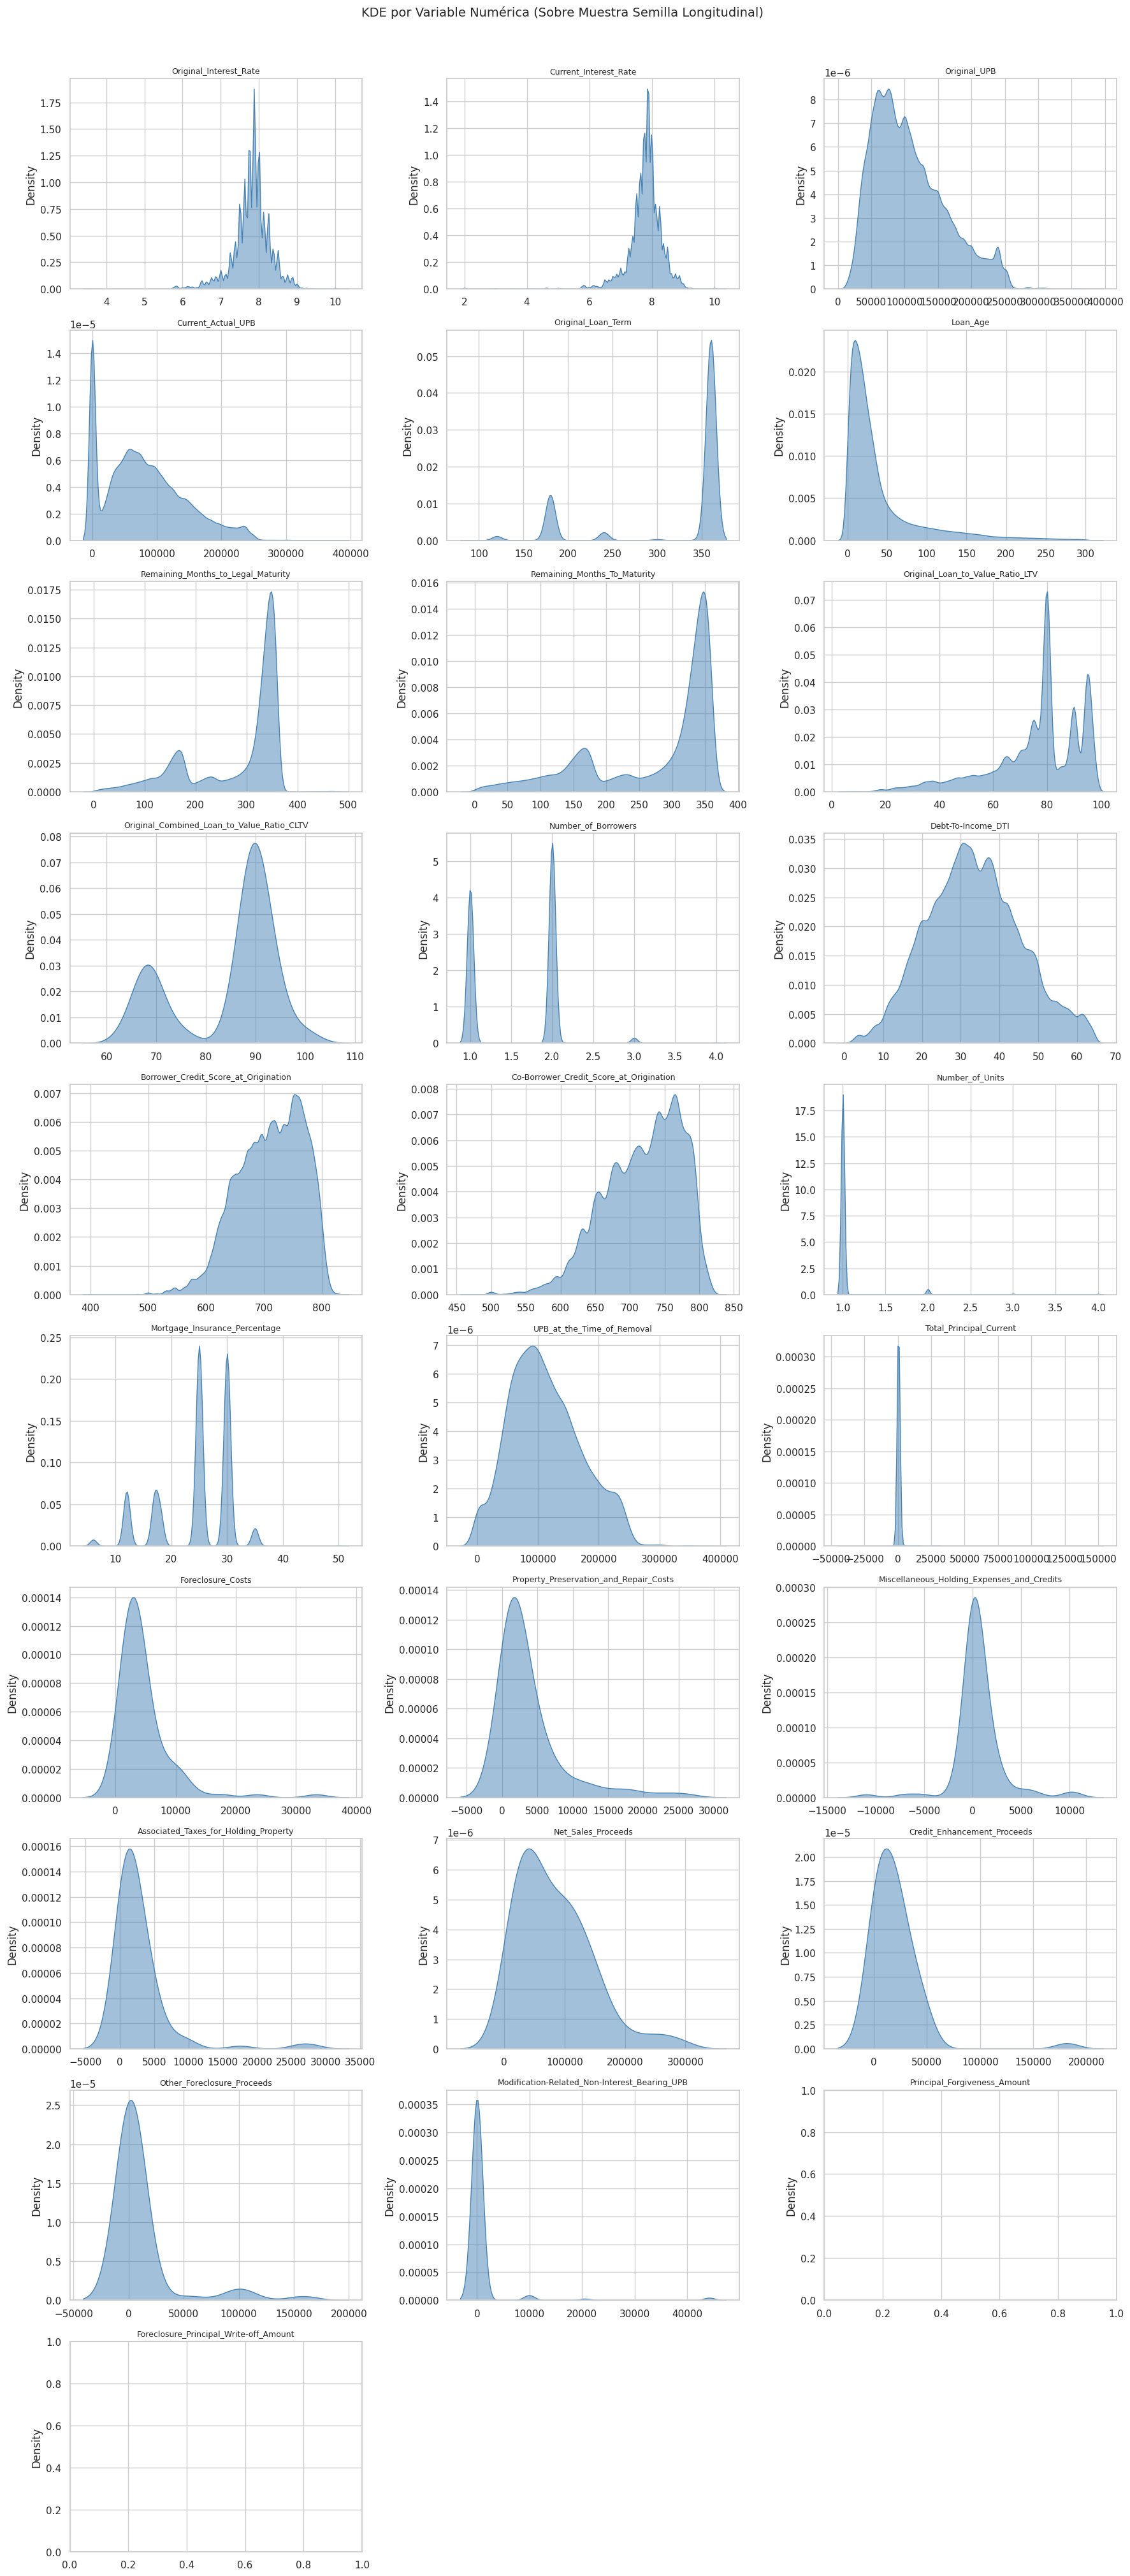

In [8]:
sns.set_theme(style='whitegrid')
n_kde = len(kde_candidates)
if n_kde > 0:
    ncols = 3
    nrows = (n_kde + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
    axes = axes.flatten() if n_kde > 1 else [axes]

    for i, col in enumerate(kde_candidates):
        ax = axes[i]
        s = pd.to_numeric(sample_pd[col], errors='coerce').dropna()
        try:
            sns.kdeplot(data=s, ax=ax, fill=True, color='steelblue', alpha=0.5)
        except Exception:
            ax.hist(s, bins=50, color='steelblue', alpha=0.6, density=True)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('KDE por Variable Numérica (Sobre Muestra Semilla Longitudinal)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No hay columnas numéricas con datos suficientes para KDE.')

1. Características del Préstamo (Términos y Tasas)
Original_Loan_Term: Es fuertemente multimodal y discreta. Tiene un pico masivo en 360 meses (30 años) y otro menor en 180 meses (15 años), lo cual es el estándar de la industria hipotecaria.

Remaining_Months_To_Maturity / to_Legal_Maturity: Presentan un fuerte sesgo a la izquierda, concentrándose en el rango de los 350-360 meses. Esto indica que la mayoría de los préstamos en esta muestra son relativamente nuevos o acaban de ser originados.

Original / Current_Interest_Rate: Muestran distribuciones en forma de campana (casi normales) centradas alrededor del 7.5% - 8%. La tasa original y la actual tienen perfiles casi idénticos.

2. Perfil de Riesgo y Prestatario
Credit_Score_at_Origination (Borrower & Co-Borrower): Ambas muestran un claro sesgo a la izquierda. La gran mayoría de los clientes tienen puntajes de crédito altos (entre 700 y 800), indicando un portafolio de bajo riesgo (Prime).

Original_Loan_to_Value_Ratio_LTV / CLTV: Tienen picos extremadamente pronunciados en 80 y 95. Esto refleja los estándares de enganche/cuota inicial típicos (20% de enganche = 80 LTV; 5% de enganche = 95 LTV).

Debt-To-Income_DTI: Distribución normal centrada entre 30 y 40. Representa el porcentaje de los ingresos destinado a deudas; los bancos suelen poner el límite de aprobación alrededor de 43-45, lo que explica la caída abrupta después de esos valores.

Number_of_Borrowers & Number_of_Units: Se comportan como variables discretas categóricas. Los prestatarios son casi exclusivamente 1 o 2, y las unidades son abrumadoramente 1.

3. Saldos y Comportamiento Financiero
Original_UPB (Unpaid Principal Balance): Sesgo a la derecha. La mayoría de los préstamos originados se concentran entre los 50,000 y 150,000, con una larga cola hacia valores más altos.

Current_Actual_UPB: Muestra un pico gigantesco exactamente en 0, lo que sugiere que una gran proporción de esta muestra corresponde a préstamos que ya fueron liquidados, cancelados o ejecutados.

Total_Principal_Current: Tiene una varianza casi nula con un pico masivo en cero.

4. Costos de Ejecución (Foreclosure) y Propiedad
Variables como Foreclosure_Costs, Property_Preservation..., Associated_Taxes..., y Net_Sales_Proceeds: Todas presentan una distribución fuertemente sesgada a la derecha. La mayoría de los registros tienen valores en cero o muy bajos, pero existe una larga cola de costos altos para las propiedades que sí entran en procesos legales de ejecución.

Mortgage_Insurance_Percentage: Muestra picos discretos y muy marcados (ej. cerca de 12, 25, 30). Las políticas de seguro hipotecario son estandarizadas, de ahí los saltos en bloque.

5. Variables Vacías o de Varianza Cero
Principal_Forgiveness_Amount y Foreclosure_Principal_Write-off_Amount: Sus gráficos están completamente en blanco, lo que indica que en esta muestra específica están compuestas 100% por valores nulos, o todos sus valores son exactamente cero (varianza cero).

---
## V. EDA — Variables categóricas (alfa-numéricas)

Identificadores, códigos de enumeración (Channel, Purpose, Delinquency, etc.) y cardinalidad.

In [9]:
id_report = []
for c in sorted(ID_COLS_SAFE):
    if c not in sample_pd.columns: continue
    ml  = GLOSSARY_META.loc[GLOSSARY_META.col_safe == c, 'max_length'].values
    n_pct = sample_pd[c].isna().mean() * 100
    id_report.append({'column': c, 'max_length': ml[0] if len(ml) else '?', 'null%': round(n_pct, 1), 'cardinality': sample_pd[c].dropna().nunique()})

print('=' * 80 + '\nIDENTIFICADORES  (Max Length N > 3 — solo cardinalidad)\n' + '=' * 80)
print(pd.DataFrame(id_report).to_string(index=False))

print('\n' + '=' * 80 + '\nCATEGÓRICOS  (Max Length N ≤ 3 — distribución + Enumerations glosario)\n' + '=' * 80)
for c in CAT_COLS:
    if c not in sample_pd.columns: continue
    s  = sample_pd[c]
    ml = GLOSSARY_META.loc[GLOSSARY_META.col_safe == c, 'max_length'].values
    n_pct = s.isna().mean() * 100
    card  = s.dropna().nunique()
    exp   = EXPECTED.get(c, [])

    print(f'\n[{c}]  MaxLen={ml[0] if len(ml) else "?"}  null={n_pct:.1f}%  card={card}')
    if exp: print(f'  Esperados: {exp}')

    vc = s.value_counts(dropna=False)
    for val, cnt in list(vc.items())[:10]:
        val_str = 'NaN/null' if pd.isna(val) else str(val)
        e_mark = '✓' if (val_str in [str(x) for x in exp] or val_str == 'NaN/null') else ''
        print(f'  {val_str:<22} {cnt:>8,}  {(cnt/len(s)*100):>6.2f}%  {e_mark}')

IDENTIFICADORES  (Max Length N > 3 — solo cardinalidad)
                           column max_length    null%  cardinality
                ARM_Cap_Structure      X(10) 100.0000            0
                 ARM_Product_Type     X(100) 100.0000            0
                        Deal_Name     X(200) 100.0000            0
                            Index     X(100) 100.0000            0
                  Loan_Identifier      X(12)   0.0000        10000
             Loan_Payment_History      X(48)  99.0000          642
                  Master_Servicer      X(10) 100.0000            0
Metropolitan_Statistical_Area_MSA       X(5)   0.0000          371
                Reference_Pool_ID       X(4) 100.0000            0
                      Seller_Name      X(50)   0.0000           32
                    Servicer_Name      X(50)  53.1000           36

CATEGÓRICOS  (Max Length N ≤ 3 — distribución + Enumerations glosario)

[Channel]  MaxLen=X(1)  null=0.0%  card=3
  Esperados: ['R', 'C', '

### V.1 Observaciones clave — Estrategia para AFM

Tras el análisis categórico, se definen las acciones para el Análisis Factorial Múltiple (AFM):

**Observaciones clave**
Tras corregir la ingesta de datos y revelar la verdadera naturaleza de las variables categóricas, el panorama para el modelado cambia radicalmente. El Análisis Factorial Múltiple (AFM) exige bloques de variables equilibrados y penaliza severamente la alta cardinalidad y la falta de varianza.

A continuación, se detallan las observaciones críticas y el plan de acción por grupos de variables:

1. Transformación Geográfica Estratégica (Reducción de Cardinalidad)
Observación: La variable Property_State cuenta con 52 categorías válidas y una distribución limpia (0% nulos). Sin embargo, inyectar 52 niveles directamente a un AFM provocará la creación de 52 dimensiones matemáticas dispersas, diluyendo la varianza explicada y sobrecargando la memoria.

Acción Requerida: Agrupación macroeconómica. Se creará una nueva característica derivada llamada Property_State_Division, mapeando los 52 estados a las 9 Divisiones del Censo de EE. UU. (Nueva Inglaterra, Atlántico Medio, Centro Noreste, Centro Noroeste, Atlántico Sur, Centro Sudeste, Centro Sudoeste, Montaña y Pacífico).

Impacto Analítico: Esto reduce la cardinalidad de 52 a 9, salvaguardando la eficiencia computacional del AFM mientras se dota al modelo de un contexto de riesgo regional inmobiliario mucho más robusto.

2. Consolidación del "Bloque Categórico" (Predictores Activos)
Observación: Varias características fundamentales de la originación hipotecaria muestran una excelente salud de datos (0% a 0.1% de nulos) y una cardinalidad ideal (entre 2 y 5 niveles).

Variables Seleccionadas: * Channel (3 niveles: R, C, B)

Loan_Purpose (3 niveles: P, C, R)

Property_Type (5 niveles: SF, PU, CO, MH, CP)

Occupancy_Status (3 niveles: P, I, S)

First_Time_Home_Buyer_Indicator (2 niveles)

Relocation_Mortgage_Indicator (2 niveles)

Acción Requerida: Estas variables conformarán el "Bloque Categórico" primario en el modelo prince.MFA, equilibrándose matemáticamente contra el "Bloque Numérico" (FICO, LTV, UPB).

3. Eliminación Fulminante por Varianza Cero (Constantes)
Observación: El reporte detectó un conjunto de variables cuya cardinalidad es exactamente 1. Es decir, el 100% de la muestra comparte el mismo valor categórico.

Amortization_Type (100% FRM)

Prepayment_Penalty_Indicator (100% N)

Special_Eligibility_Program (100% 7)

High_Balance_Loan_Indicator (100% N)

Payment_Deferral_Modification_Event_Indicator (100% 7)

Acción Requerida: Eliminación masiva del dataset analítico (.drop()). Matemáticamente, una constante carece de varianza; incluirla en cualquier modelo basado en correlaciones generará singularidades y fallos de convergencia en las matrices.

4. Aislamiento de Fugas Temporales y Variable Objetivo
Observación sobre el Target: La variable Zero_Balance_Code se lee correctamente, revelando los eventos de terminación del préstamo. Códigos como 09 (Foreclosure) y 06 (Repurchase) representan el incumplimiento real.

Acción: Reservar esta columna exclusivamente para derivar la etiqueta de clasificación final (Target_Default: 1/0).

Observación sobre Fugas de Tiempo: Current_Loan_Delinquency_Status tiene 101 niveles que cambian mes a mes (00, 01, XX).

Acción: Excluirla estrictamente del AFM (que evalúa el riesgo en el momento de originación). Esta variable pertenece únicamente a la entrada temporal del modelo de secuencias (Autoencoder/RNN) en la Fase 4.

5. Contención de Cardinalidad Extrema (Zip_Code_Short)
Observación: El código postal truncado mantiene 794 valores únicos.

Acción Requerida: Excluir del AFM. Dado que el modelo ya capturará la varianza geográfica macro a través de las 9 Divisiones del Censo, incluir el código postal generaría un nivel de dispersión inmanejable para las dimensiones latentes. Si se requiere usar más adelante, deberá someterse a Target Encoding.



In [ ]:
# Columnas numéricas clave para la matriz de correlación
cols_corr = [
    'Original_Interest_Rate', 'Borrower_Credit_Score_at_Origination',
    'Original_Loan_to_Value_Ratio_LTV', 'Debt-To-Income_DTI', 'Original_UPB',
    'Number_of_Borrowers', 'Loan_Age', 'Mortgage_Insurance_Percentage'
]
cols_present = [c for c in cols_corr if c in sample_pd.columns]

if cols_present:
    corr = sample_pd[cols_present].dropna().corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Matriz de Correlación — Variables Numéricas (Muestra)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron columnas numéricas para la correlación.')

## VIII. Conclusiones — Arquitectura para AFE, AFC y AFM

Tras el análisis exhaustivo de las distribuciones, cardinalidades y valores nulos del portafolio Freddie Mac, se concluye que el dataset crudo no es apto para ser ingerido directamente por algoritmos de reducción de dimensionalidad basados en varianza y covarianza (como el Análisis Factorial).

Para garantizar la convergencia matemática, evitar la maldición de la dimensionalidad y prevenir la fuga de información (data leakage), se establece la siguiente estrategia de preprocesamiento y partición en 4 fases metodológicas:

Fase 1: Poda y Contención (Data Cleansing & Winsorization)
Antes de cualquier análisis factorial, el espacio de datos debe ser estabilizado:

Eliminación por Varianza Cero (Constantes): Se descartan fulminantemente las variables que no aportan varianza (Amortization_Type, Prepayment_Penalty_Indicator, Principal_Forgiveness_Amount, etc.).

Eliminación por Esparcidad Extrema: Se excluyen del modelo de originación las 42 variables con >50% de nulos (ej. Foreclosure_Costs). Se reservan únicamente para modelos paralelos de severidad de pérdida (LGD).

Contención de Asimetría (Winsorizing): Para evitar que las largas colas de las variables financieras distorsionen las matrices de correlación del AFM, se aplicará clipping intercuartílico (IQR) a 13 variables críticas (ej. acotar Original_UPB entre $25k y $248k, y Borrower_Credit_Score entre 570 y 804).

Fase 2: Ingeniería de Características y Tratamiento Lógico
Los "nulos lógicos" y las variables discretas disfrazadas de continuas requieren un tratamiento de negocio específico:

Nulos Estructurales: * Mortgage_Insurance_Percentage: Se imputa con 0.0 (ausencia de seguro).

Co-Borrower_Credit_Score: Se crea una nueva característica Max_Household_Score para absorber la falta de co-deudor sin afectar la media poblacional.

Agrupación Geográfica: Property_State (52 niveles) se transforma en Property_State_Division (9 niveles de las Divisiones del Censo) para reducir dimensionalidad espacial. Zip_Code_Short se excluye temporalmente.

Conversión Categórica: Variables numéricas con comportamiento discreto rígido (Original_Loan_Term con picos en 180 y 360, Number_of_Borrowers, Number_of_Units) dejarán de ser numéricas y se tratarán como categóricas/ordinales para el AFM.

Fase 3: Partición del Espacio Analítico (Prevención de Fugas)
Para predecir el riesgo real, debemos separar estrictamente lo que el banco sabía en el momento de aprobar el crédito (T=0) de cómo se comportó el crédito después (T>0).

Matriz Target: Zero_Balance_Code (Transformada a binaria: Default / No Default).

Matriz Dinámica (Para Autoencoder / RNN): Variables longitudinales mes a mes (Current_Interest_Rate, Current_Actual_UPB, Loan_Age, Current_Loan_Delinquency_Status). Estrictamente prohibidas en el Análisis Factorial de Originación.

Matriz Estática de Originación (Para AFE/AFC/AFM): Variables ancladas al momento de la firma.

Fase 4: Diseño del Análisis Factorial Múltiple (AFM)
Una vez limpia, la Matriz Estática de Originación se dividirá en grupos (bloques) equilibrados para el Análisis Factorial Múltiple, el cual exige separar naturalezas estadísticas:

Bloque 1: Riesgo Crediticio y Financiero (Numérico Contínuo)

Variables: Original_Interest_Rate (Winsorizada), Original_UPB (Log-transformada/Winsorizada), Original_Loan_to_Value_Ratio_LTV, Debt-To-Income_DTI, FICO Score.

Estrategia: Sobre este bloque continuo se ejecutará primero el AFE (Análisis Factorial Exploratorio) en una submuestra para encontrar factores latentes (ej. "Capacidad de Pago", "Apalancamiento"), validando la estructura luego con un AFC (Análisis Factorial Confirmatorio).

Bloque 2: Perfil del Préstamo y Propiedad (Categórico)

Variables: Channel, Loan_Purpose, Property_Type, Occupancy_Status, Property_State_Division, Original_Loan_Term (Binarizada 15/30 años).

Estrategia: Se aplicará codificación (One-Hot / MCA) internamente en el algoritmo de AFM para ponderar estas categorías frente a la inercia del Bloque 1.

## VII. Visualizaciones

### 7.1 Matriz de correlación (variables numéricas clave)